In [1]:
# Basic Libraries
import numpy as np
import pandas as pd

In [2]:

# Visualization libraries
import matplotlib.pyplot as plt
import pydot
import seaborn as sns

In [3]:
#!pip install pydot

In [4]:
#Evaluation library
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [5]:
# Deep Learning libraries
import tensorflow as tf
from tensorflow.keras import layers
import keras
from keras.models import Sequential
from keras.layers import Dense,Activation,Dropout
from keras.datasets import mnist
from keras.utils import to_categorical
from scikeras.wrappers import KerasClassifier

In [6]:
#!pip install scikeras

In [7]:
#Digit MNIST dataset
(X_train_digit, y_train_digit), (X_test_digit, y_test_digit) = mnist.load_data()

In [8]:
print (y_train_digit)

[5 0 4 ... 5 6 8]


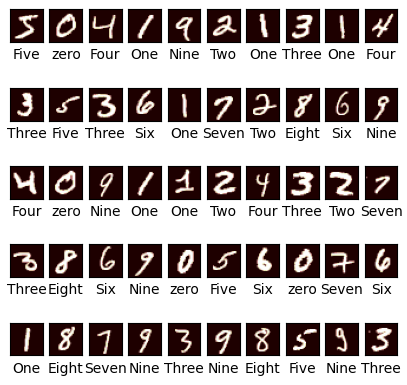

In [9]:
#Names of numbers in the dataset in order
col_names = ['zero','One','Two','Three','Four','Five','Six','Seven','Eight','Nine','ten']

#Visualizing the digits
plt.figure(figsize=(5,10)) # size of image space between rows
for i in range(50):
    plt.subplot(10,10,i+1)# rows and columns i+1 =1 then print numbers
    plt.xticks([]) #hide xticks
    plt.yticks([]) #hide yticks
    plt.imshow(X_train_digit[i], cmap='pink')
    plt.xlabel(col_names[y_train_digit[i]]) # how it gets print it is based on output image number suppose if the number is 5 then the label also gets five
plt.show()

changing from 3D to 2D for the DL

In [10]:
X_train_digit.shape

(60000, 28, 28)

In [11]:
X_train_digit=X_train_digit.reshape(60000,784)
X_test_digit=X_test_digit.reshape(10000,784)


In [12]:
X_test_digit.shape

(10000, 784)

output pro-processing technique in ANN One Hot Encoading

In [13]:
y_train_digit.shape

(60000,)

In [14]:
y_train_digit=to_categorical(y_train_digit,num_classes=10)#Classes number of classses example 1,2,3...10
y_test_digit=to_categorical(y_test_digit,num_classes=10)

In [15]:
y_train_digit

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], shape=(60000, 10))

In [16]:
#creating base neural network just a procedure
model=keras.Sequential([
    layers.Dense(256,activation='relu',input_shape=(784,)),# 256 is hyper tuning parameters, activation is calculations 0 to max. #Hidden layer(Revision test 1)
    layers.Dense(64,activation='relu'), #Hidden layer(Revision test 2)
    layers.Dense(64,activation='relu'), #Hidden layer(Revision test 3)
    layers.Dense(10,activation='sigmoid'), #Output layer(output),
])
    
    

C:\Anaconda\envs\aiml\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.summary()
#Formula= o/p channle * i/p channel+1
#ex dense 1 = 64*(256+1)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 222,218 (868.04 KB)

 Trainable params: 222,218 (868.04 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
#Compile method
model.compile(loss="categorical_crossentropy",#measures how far the prediction is from the actual answer.
              optimizer="adam",#adjusts the neural-network weights to reduce the loss.
              metrics=['accuracy'])#tells you the percentage of correct predictions.

In [27]:
#Fit method where learning starts
#history=model.fit(X_train_digit, y_train_digit,batch_size=20000,epochs=5)
history=model.fit(X_train_digit, y_train_digit,batch_size=20000,epochs=5,validation_data=(X_test_digit, y_test_digit))

Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 262ms/step - accuracy: 0.8302 - loss: 0.0011 - val_accuracy: 0.8104 - val_loss: 0.1081
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 263ms/step - accuracy: 0.8301 - loss: 0.0011 - val_accuracy: 0.8104 - val_loss: 0.1081
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 238ms/step - accuracy: 0.8299 - loss: 0.0011 - val_accuracy: 0.8102 - val_loss: 0.1082
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 252ms/step - accuracy: 0.8298 - loss: 0.0010 - val_accuracy: 0.8102 - val_loss: 0.1082
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 226ms/step - accuracy: 0.8297 - loss: 0.0010 - val_accuracy: 0.8102 - val_loss: 0.1083


In [32]:
y_predict=model.predict(X_test_digit)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [30]:
y_predict[0]

array([0.93380874, 0.98785603, 0.99982804, 0.99178606, 0.9995073 ,
       0.06025286, 0.4602782 , 1.        , 0.79672784, 0.99097973],
      dtype=float32)

In [36]:
y_prdicts=np.argmax(y_predict,axis=1)#reversal of pre-processed output based on test data.
y_prdicts

array([7, 0, 1, ..., 4, 0, 6], shape=(10000,))

In [37]:
y_text_digit_eval=np.argmax(y_test_digit,axis=1)#Actual test set data
y_text_digit_eval

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

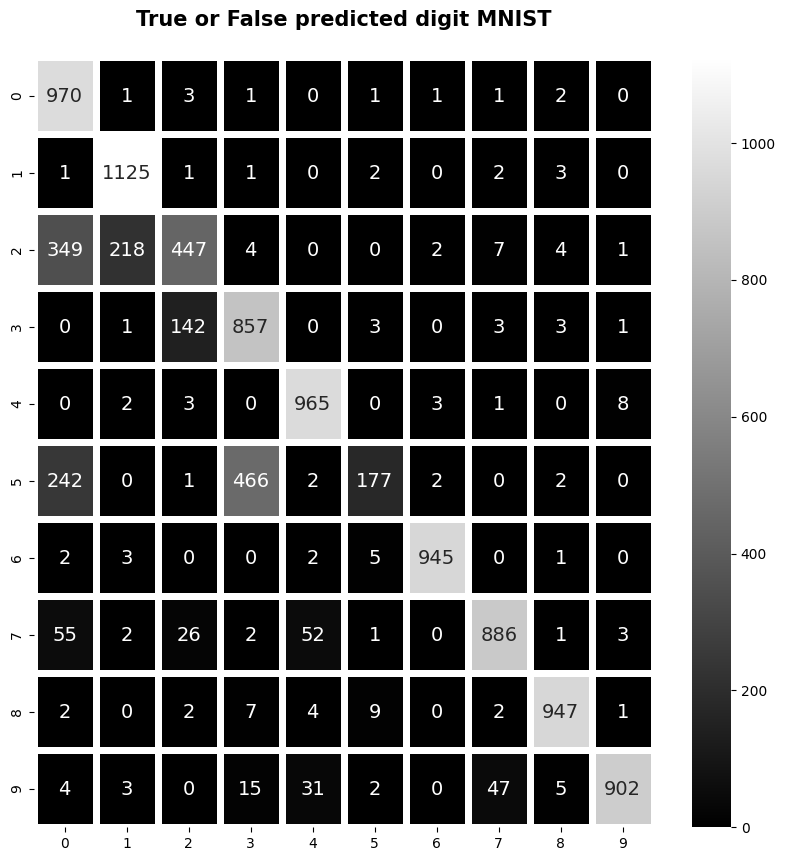

In [62]:
#Confusion Metrics
con_mat=confusion_matrix(y_text_digit_eval,y_prdicts)
plt.style.use('seaborn-v0_8-deep')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat,annot=True,annot_kws={'size':14},linewidths=5,fmt="d",cmap="gray")
plt.title('True or False predicted digit MNIST\n',fontweight='bold',fontsize=15)
plt.show()

In [66]:
from sklearn.metrics import classification_report

print(classification_report(y_text_digit_eval,y_prdicts))

              precision    recall  f1-score   support

           0       0.60      0.99      0.74       980
           1       0.83      0.99      0.90      1135
           2       0.72      0.43      0.54      1032
           3       0.63      0.85      0.73      1010
           4       0.91      0.98      0.95       982
           5       0.89      0.20      0.32       892
           6       0.99      0.99      0.99       958
           7       0.93      0.86      0.90      1028
           8       0.98      0.97      0.98       974
           9       0.98      0.89      0.94      1009

    accuracy                           0.82     10000
   macro avg       0.85      0.82      0.80     10000
weighted avg       0.84      0.82      0.80     10000



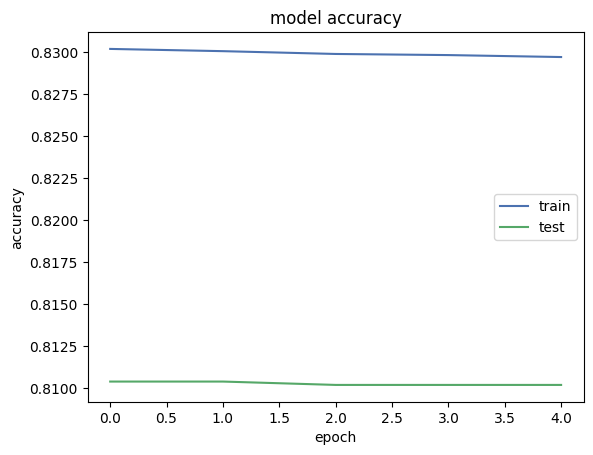

In [67]:
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()


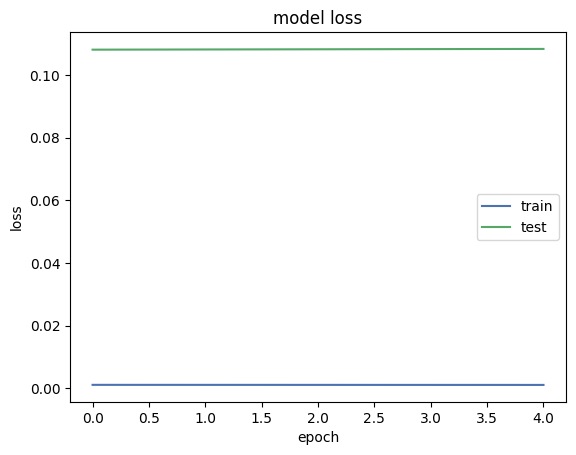

In [68]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()